In [ ]:
#Aliexpress KSA  - Discount Strategy Decoder 
# EDA : Exploratory Data Analysis + feature engineering + data visualization

1.Importing all required libraries 

In [1]:
%pip install matplotlib seaborn
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt #base plotting 
import seaborn as sns #build statistical charts 
import warnings 
warnings.filterwarnings('ignore')
print("done")

Note: you may need to restart the kernel to use updated packages.
done


2.Display settings 

In [3]:
pd.set_option('display.max_columns', None) # Show all columns without truncation (by default pandas hides columns)
pd.set_option('display.max_colwidth', 60) # Limit column width so long titles don't overflow
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
# Set a clean visual theme for all plots
#style='whitegrid' white background with light grey lines 
#palette='muted'→ uses softer, less saturated colours (more pro)
#font_scale=1.1→ makes all text in plots 10% larger than default
plt.rcParams['figure.dpi'] = 120 # High resolution figures (dots per inch)
print("done")

done


3.Load the dataset 

In [4]:
import os
os.getcwd()
#returns full path of the folder where Python is currently running from.

'C:\\Users\\samiy\\Aliexpress-pricing-strategy-ML\\notebooks'

In [4]:
df_original = pd.read_csv('../data/raw_csv.csv')  # keep original untouched
df = df_original.copy()                      # always work on a copy

In [6]:
print(f"   Rows    : {df.shape[0]}")
#number of rows 

   Rows    : 864270


In [7]:
print(f"   Columns : {df.shape[1]}")
#number of columns 

   Columns : 17


In [40]:
df.head()

,id,storeId,storeName,title,rating,lunchTime,category,postCategory,sold,price,discount,shippingCost,imageUrl,storeUrl,category_name,category_id,type
0,1005002508947205,900250272,IDEACH Official Store,Wireless Handheld Vacuum Cleaner 10kPa 150W Powerful Dua...,4.8,2021-04-19 00:00:00,NaN,608,1487 sold,464.16,76,0.0,//ae01.alicdn.com/kf/S29307438fb224285b2981d71eb2b7835o/...,//www.aliexpress.com/store/900250272,home-appliances,6,natural
1,1005004546160959,5379102,Factory Direct Collected Store,Portable Water Drop Humidifier USB Desktop Indoor Air At...,4.8,2022-07-19 00:00:00,NaN,625,5348 sold,22.28,54,0.0,//ae01.alicdn.com/kf/S8d4807ce10bd4152850ec872f2cea460y/...,//www.aliexpress.com/store/5379102,home-appliances,6,natural
2,1005004967489874,911794975,HOMDD Specialty Store,Portable Desktop Instant Automatic Multi-Speed Fast Hot ...,0.0,2022-11-17 00:00:00,NaN,610,1 sold,251.76,25,0.0,//ae01.alicdn.com/kf/Sdae1fa83cf1a482397b6e061cb5b6325T/...,//www.aliexpress.com/store/911794975,home-appliances,6,natural
3,1005003601452827,912652146,XINGHUO ONLINE Store,Portable 420ml Air Humidifier Aroma Oil Humidificador fo...,4.7,2021-11-24 00:00:00,NaN,625,2979 sold,8.95,84,0.0,//ae01.alicdn.com/kf/Se200f7a404974c87b5941587a1201c5dh/...,//www.aliexpress.com/store/912652146,home-appliances,6,natural
4,33022569739,4991203,ABIR Official Store,ABIR X6 Robot Vacuum Cleaner Visual Navigation APP Virt...,4.7,2019-05-24 00:00:00,NaN,608,2103 sold,775.35,59,0.0,//ae01.alicdn.com/kf/Scfe6fa94f0644aaabff79c0f3af5cb6fZ/...,//www.aliexpress.com/store/4991203,home-appliances,6,ad


In [42]:
df.info() #info about columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 864270 entries, 0 to 864269
Data columns (total 17 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   id             864270 non-null  int64  
 1   storeId        864270 non-null  int64  
 2   storeName      864270 non-null  object 
 3   title          864270 non-null  object 
 4   rating         864270 non-null  float64
 5   lunchTime      864270 non-null  object 
 6   category       0 non-null       float64
 7   postCategory   864270 non-null  int64  
 8   sold           864270 non-null  object 
 9   price          864270 non-null  float64
 10  discount       864270 non-null  int64  
 11  shippingCost   798072 non-null  float64
 12  imageUrl       864270 non-null  object 
 13  storeUrl       864270 non-null  object 
 14  category_name  864270 non-null  object 
 15  category_id    864270 non-null  int64  
 16  type           864270 non-null  object 
dtypes: float64(4), int64(5), obje

Descreptive statistics 

In [10]:
df.describe().round(2)
# count, mean, std (standard deviation), min, 25%, 50%, 75%, max
#.round(2) keeps it readable

,id,storeId,rating,category,postCategory,price,discount,shippingCost,category_id
count,8.642700e+05,8.642700e+05,864270.00,0.0,8.642700e+05,864270.00,864270.00,798072.00,8.642700e+05
mean,9.080601e+14,5.226033e+08,2.27,NaN,1.229935e+08,221.45,30.90,91.02,1.387867e+08
std,2.963877e+14,4.956751e+08,2.40,NaN,8.922083e+07,2297.69,19.99,6154.51,8.237863e+07
min,1.008900e+04,1.000300e+04,0.00,NaN,1.450000e+02,0.01,0.00,0.00,5.000000e+00
25%,1.005003e+15,4.291033e+06,0.00,NaN,3.806100e+05,13.94,15.00,0.00,1.000016e+08
50%,1.005004e+15,9.104512e+08,0.00,NaN,2.000003e+08,38.34,32.00,12.20,2.000021e+08
75%,1.005005e+15,9.125601e+08,5.00,NaN,2.000039e+08,110.64,48.00,22.35,2.002153e+08
max,1.010000e+15,1.102528e+09,5.00,NaN,2.018986e+08,976428.20,99.00,2896137.06,2.060891e+08


describe categorical 

In [11]:
df.describe(include='object')
# include='object' targets non-numeric columns

,storeName,title,lunchTime,sold,imageUrl,storeUrl,category_name,type
count,864270,864270,864270,864270,864270,864270,864270,864270
unique,99468,595296,3700,4923,626402,99362,325,2
top,ETENITY BOWLING Store,USB Plug Lamp Computer Mobile Power Charging USB Small B...,2022-11-30 00:00:00,0,//ae01.alicdn.com/kf/He3ab12dee7de4a5cb0da87a5ead0de5dF/...,//www.aliexpress.com/store/5570009,home-appliances,natural
freq,1940,57,6158,286051,21,1941,7256,808610


so from those statistics : 
 >99468 stores
 ,325 categories
 ,2 types : ad , natural

 Value counts for categorical columns

In [12]:
#type tell us if the product is natural or advertised 
print("=== Product Type ===")
print(df['type'].value_counts())
#in percentage 
print("As percentage:")
print(df['type'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')


=== Product Type ===
type
natural    808610
ad          55660
Name: count, dtype: int64
As percentage:
type
natural    93.6%
ad          6.4%
Name: proportion, dtype: object


In [13]:
# Top 10 most common product categories
print("=== Top 5 Product Categories ===")
print(df['category_name'].value_counts().head(5))
print()

=== Top 5 Product Categories ===
category_name
home-appliances         7256
lights-lighting         6296
arts-crafts-diy-toys    3900
kitchen-dining-bar      3899
iot-devices             3895
Name: count, dtype: int64



# category and type analysis

In [9]:
# Average metrics: Ad vs Natural products
# The 'sold' column was scraped with a "sold" prefix ("sold972")
df['sold'] = pd.to_numeric(
    df['sold'].astype(str).str.replace('sold', '', regex=False),
    errors='coerce'   # unparseable values become NaN instead of raising
)

print("=== Average metrics: ad vs natural ===")
# Group by product type and compute the mean of key performance columns
print(df.groupby('type')[['sold', 'price', 'discount', 'rating']].mean().round(2))
print()



=== Average metrics: ad vs natural ===
           sold   price  discount  rating
type                                     
ad       272.32  365.41      38.1    3.04
natural   68.80  211.54      30.4    2.22



#  Top 10 Categories by Avg Units Sold 

**Top 10 Categories by Avg Units Sold **


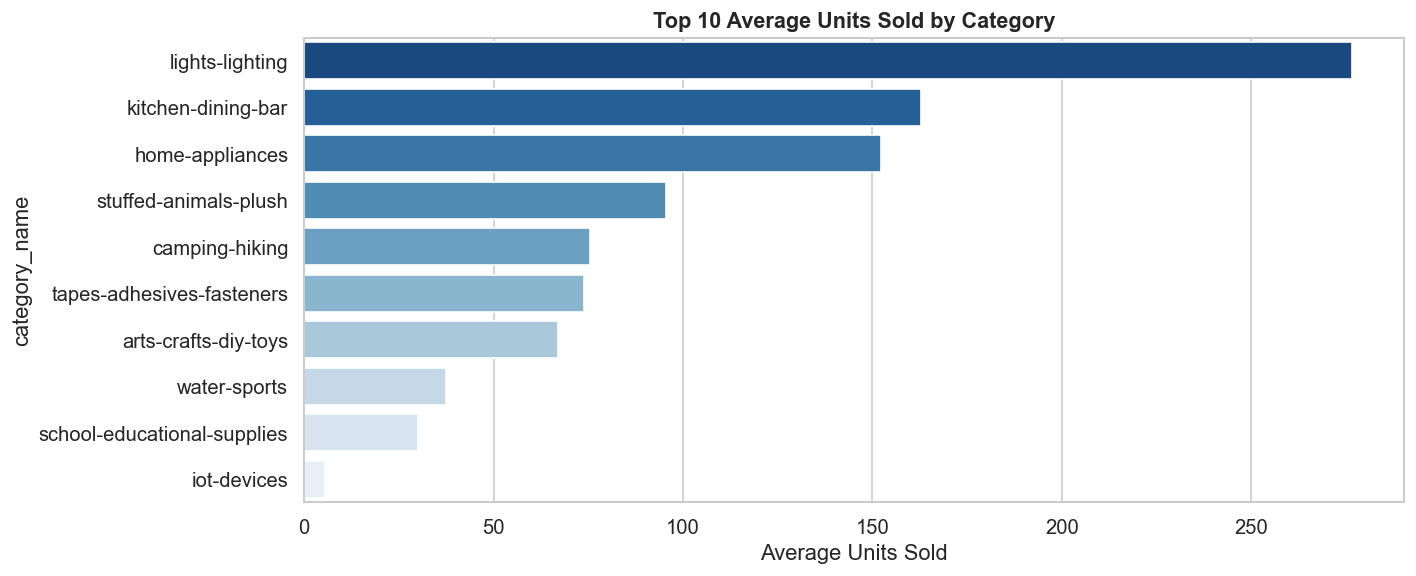

In [10]:
# Find the 10 most frequent categories by product count
top_cats = df['category_name'].value_counts().head(10).index

# Filter to only those categories, then compute mean units sold per category
# sort_values puts the best-selling category at the top of the chart
cat_analysis = (
    df[df['category_name'].isin(top_cats)]   # keep only top-10 categories
    .groupby('category_name')['sold']
    .mean()
    .sort_values(ascending=False)            # descending so best is first
)

print("**Top 10 Categories by Avg Units Sold **")  

# Horizontal bar chart  =easier to read long category names on the y-axis
plt.figure(figsize=(12, 5))
sns.barplot(
    x       = cat_analysis.values,   # average units sold (x-axis)
    y       = cat_analysis.index,    # category names (y-axis)
    palette = 'Blues_r'              # darker blue = higher sales (reversed)
)
plt.title('Top 10 Average Units Sold by Category', fontsize=13, fontweight='bold')
plt.xlabel('Average Units Sold')
plt.tight_layout()  # prevent label clipping
plt.show()

so its logic that most sales and discounts will be on top categories 

# Missing Values Analysis 

1. **missing values**(NaN) we should find which columns have missing values and how many



2.**Decide** how to handle it (fill, drop , keep)

In [43]:
#count and pourcentage of missing values 
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),        # total NaN per column
    'Missing %'    : (df.isnull().sum() / len(df) * 100).round(2)  # as percentage
})
# Only show columns that actually have missing values
missing = missing[missing['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print(missing)
# % how serious it is 

              Missing Count  Missing %
category             864270     100.00
shippingCost          66198       7.66


so the column "category" is missing so we will drop it 

In [44]:
df = df.drop(columns=['category'])
print("Dropped 'category' ")


Dropped 'category' 


in our dataset we already have : category_name,category_id so we will drop the column category.for shipping we will fill it with mean cause it is a numerical value 

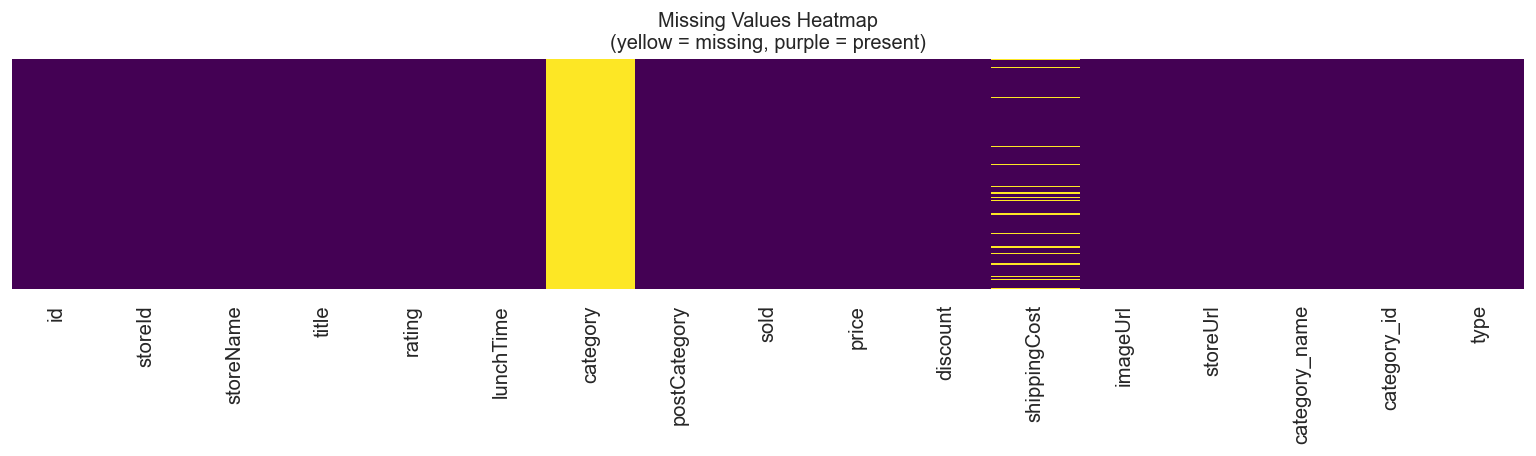

In [16]:
plt.figure(figsize=(13, 4))
#heatmap is a data visualization tool that uses color-coding to represent intensity or density,
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
# cbar=False      > hide the color scale bar on the side 
# yticklabels=False > hide row numbers on the y-axis 
plt.title('Missing Values Heatmap\n(yellow = missing, purple = present)', fontsize=12)
#Yellow= missing value, purple = present value 
# Prevent labels from being cut off at the edges
plt.tight_layout()
plt.show()

Fill missing values : i tried to fill with mean of shippinCost but that were illogic cause many of them are 0 (free shipping) A mean of 91 for shipping cost is suspicious.
(91.02)

In [45]:
df['shippingCost'] = df['shippingCost'].fillna(0) # fill it with 0
print(f"Filled {df['shippingCost'].isna().sum()} missing shippingCost with 0")

Filled 0 missing shippingCost with 0


just to make sure : 

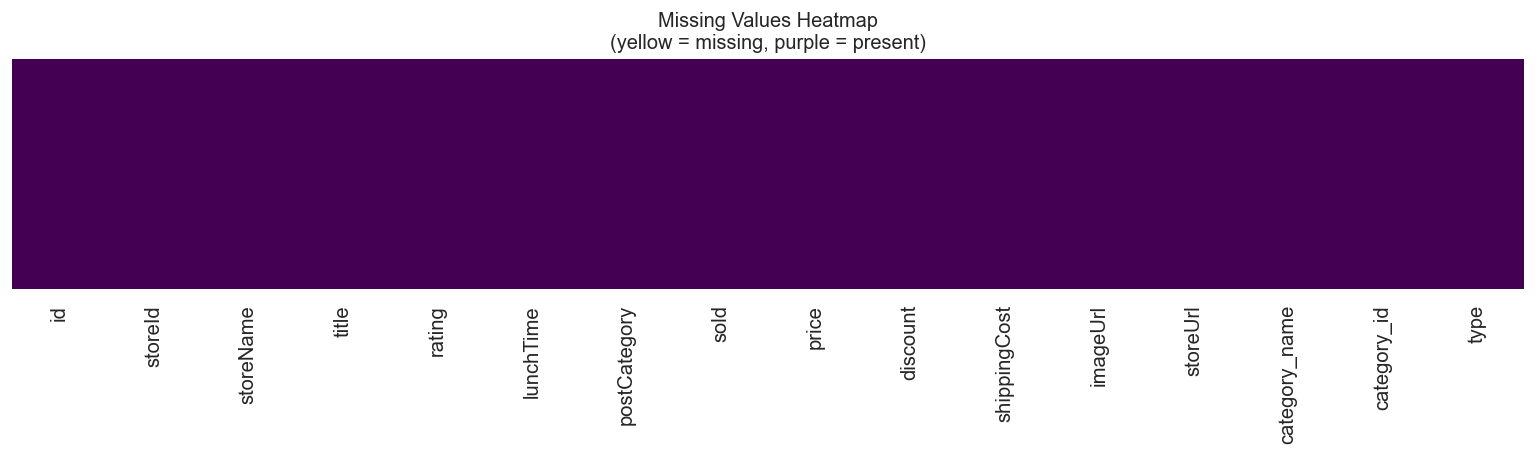

In [46]:
plt.figure(figsize=(13, 4))
#heatmap is a data visualization tool that uses color-coding to represent intensity or density,
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
# cbar=False      → hide the color scale bar on the side (not needed here)
# yticklabels=False → hide row numbers on the y-axis (too many to display)
plt.title('Missing Values Heatmap\n(yellow = missing, purple = present)', fontsize=12)
#Yellow= missing value, purple = present value 
# Prevent labels from being cut off at the edges
plt.tight_layout()
plt.show()
# 

In [17]:
# A duplicate row is an exact copy of another row
n_duplicates = df.duplicated().sum()
print(f"Duplicate rows found: {n_duplicates}")


Duplicate rows found: 152846


Remove duplicates : 

In [47]:
print(f"\n before removing duplicates: {df.shape}")
df = df.drop_duplicates()
print(f"after  removing duplicates: {df.shape}")


 before removing duplicates: (864270, 16)
after  removing duplicates: (711168, 16)


Clean 'sold'column  (number + sold)=remove the word "sold"

In [48]:
df['sold'] = (
    df['sold']
    .astype(str)
    .str.replace('sold', '', case=False)
    .str.replace(',', '')
    .str.strip()
    .replace('', np.nan)
    .astype(float)
)
print("done")

done


what other columns dropped ? 

In [55]:
df = df.drop(columns=[
    'id',          # just a row number
    'imageUrl',    # URL string, useless for us 
    'title',       # free text
    'storeName',   # redundant with storeId
    'postCategory' # redundant with category_id + category_name
])

print(" Dropped columns")
print(f"Remaining columns: {df.columns.tolist()}")


 Dropped columns
Remaining columns: ['storeId', 'rating', 'lunchTime', 'sold', 'price', 'discount', 'shippingCost', 'storeUrl', 'category_name', 'category_id', 'type']


## Distributions
-view key variables distributions 

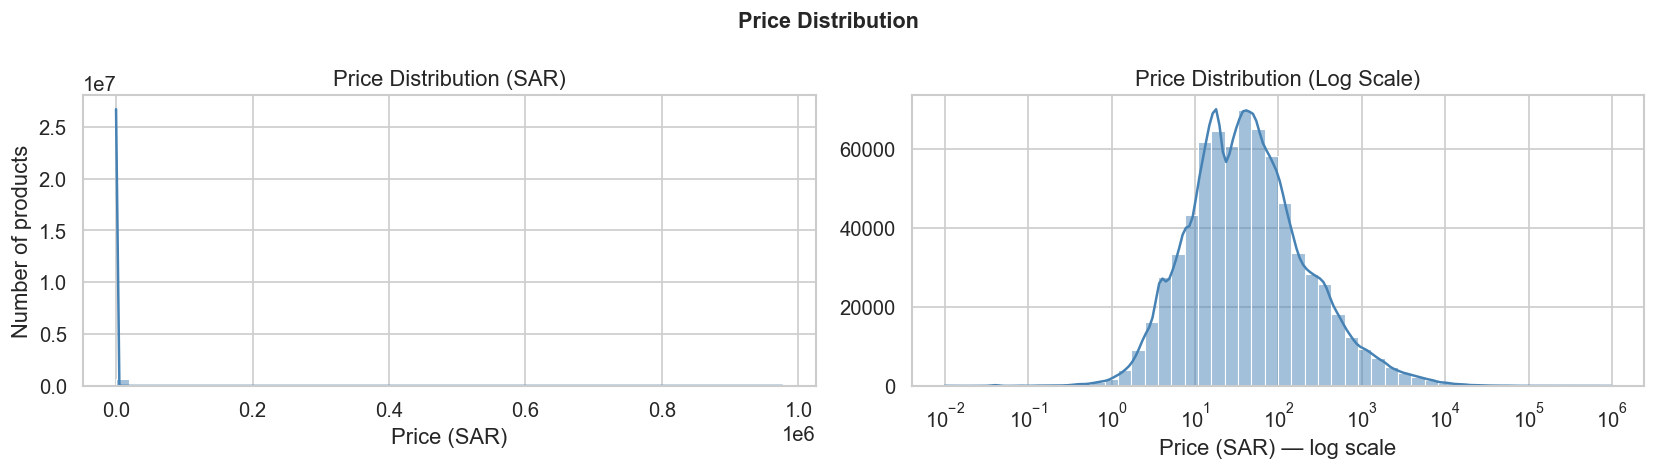

Min price    : 0.01 SAR
Max price    : 976428.20 SAR
Mean price   : 227.55 SAR
Median price : 38.57 SAR


In [49]:

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: raw distribution
# kde=True adds a smooth curve showing the shape of the distribution
sns.histplot(df['price'], bins=50, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Price Distribution (SAR)')
axes[0].set_xlabel('Price (SAR)')
axes[0].set_ylabel('Number of products')

# Right: log scale — useful when data is heavily skewed
# Log scale compresses extreme values so we can see the full range
sns.histplot(df['price'][df['price'] > 0], bins=50, kde=True,
             ax=axes[1], color='steelblue', log_scale=True)
axes[1].set_title('Price Distribution (Log Scale)')
axes[1].set_xlabel('Price (SAR) — log scale')
axes[1].set_ylabel('')

plt.suptitle('Price Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Quick summary stats for price
print(f"Min price    : {df['price'].min():.2f} SAR")
print(f"Max price    : {df['price'].max():.2f} SAR")
print(f"Mean price   : {df['price'].mean():.2f} SAR")
print(f"Median price : {df['price'].median():.2f} SAR")

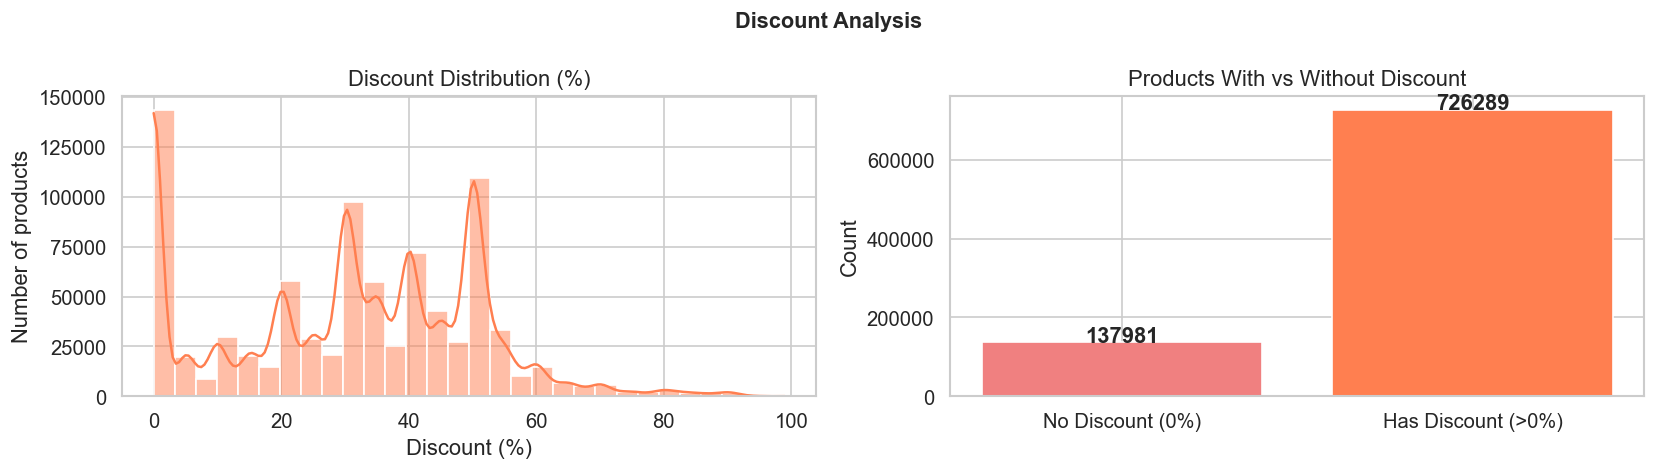

Products with no discount : 137981  (16.0%)
Products with a discount  : 726289 (84.0%)


In [20]:

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: full discount distribution (0 to 100%)
sns.histplot(df['discount'], bins=30, kde=True, ax=axes[0], color='coral')
axes[0].set_title('Discount Distribution (%)')
axes[0].set_xlabel('Discount (%)')
axes[0].set_ylabel('Number of products')

# Right: how many products have a discount vs none?
# This is a key insight for our pricing strategy analysis
zero_disc    = (df['discount'] == 0).sum()
nonzero_disc = (df['discount'] >  0).sum()

axes[1].bar(
    ['No Discount (0%)', 'Has Discount (>0%)'],
    [zero_disc, nonzero_disc],
    color=['lightcoral', 'coral'],
    edgecolor='white'
)
axes[1].set_title('Products With vs Without Discount')
axes[1].set_ylabel('Count')

# Add count labels on top of bars
for i, v in enumerate([zero_disc, nonzero_disc]):
    axes[1].text(i, v + 20, str(v), ha='center', fontweight='bold')

plt.suptitle('Discount Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Products with no discount : {zero_disc}  ({zero_disc/len(df)*100:.1f}%)")
print(f"Products with a discount  : {nonzero_disc} ({nonzero_disc/len(df)*100:.1f}%)")

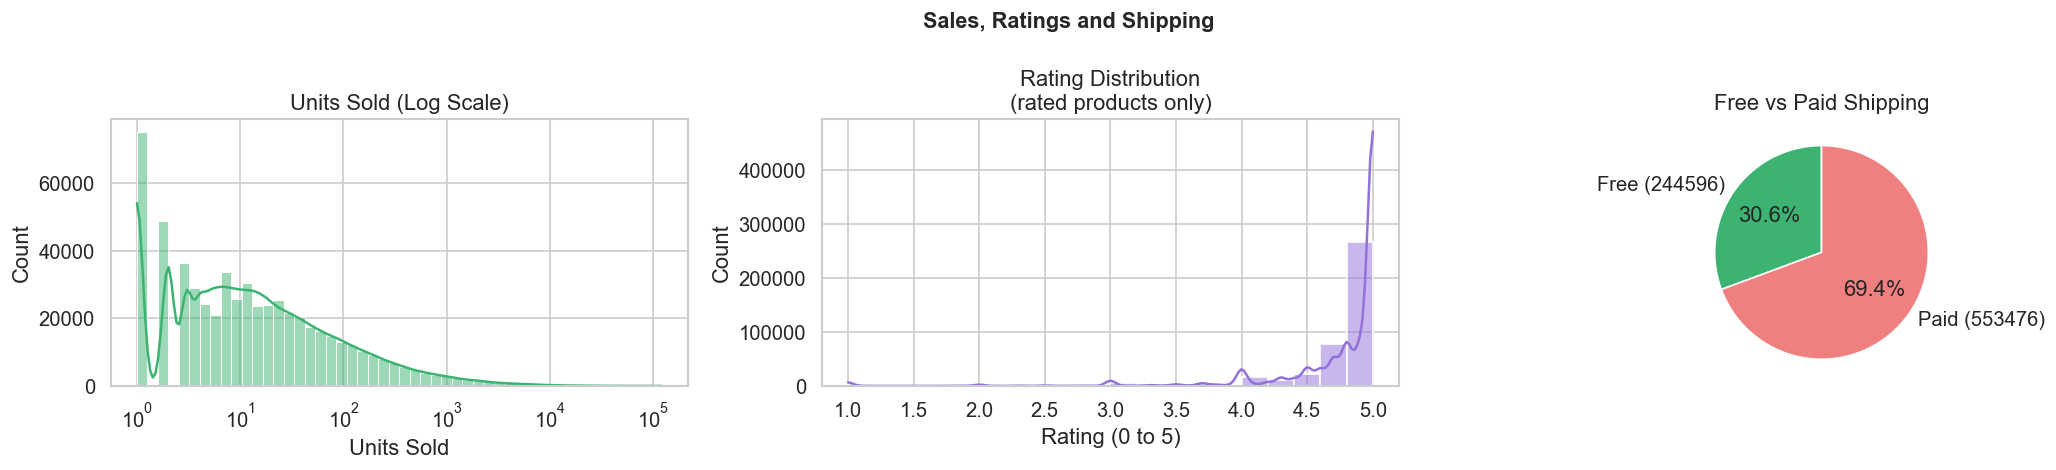

Products with no rating (0) : 451432
Free shipping products      : 244596 (28.3%)


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
# Sold count (log scale because it's very skewed) 
# Most products sell very few units; a few sell thousands
# 1. Remove the word 'sold' and any extra spaces
# 2. Convert the column to numeric (integers or floats)
df['sold'] = df['sold'].str.replace('sold', '', case=False).str.strip().astype(float)

# Now your plotting code will work perfectly
sns.histplot(df['sold'][df['sold'] > 0], bins=50, kde=True,
             ax=axes[0], color='mediumseagreen', log_scale=True)

axes[0].set_title('Units Sold (Log Scale)')
axes[0].set_xlabel('Units Sold')
axes[0].set_ylabel('Count')

# Rating distribution 
# Products with rating = 0 are unrated (new listings)
sns.histplot(df['rating'][df['rating'] > 0], bins=20, kde=True,
             ax=axes[1], color='mediumpurple')
axes[1].set_title('Rating Distribution\n(rated products only)')
axes[1].set_xlabel('Rating (0 to 5)')

#  Shipping cost (free vs paid) 
free = (df['shippingCost'] == 0).sum()
paid = (df['shippingCost'] >  0).sum()
axes[2].pie(
    [free, paid],
    labels=[f'Free ({free})', f'Paid ({paid})'],
    autopct='%1.1f%%',
    colors=['mediumseagreen', 'lightcoral'],
    startangle=90
)
axes[2].set_title('Free vs Paid Shipping')

plt.suptitle('Sales, Ratings and Shipping', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Products with no rating (0) : {(df['rating'] == 0).sum()}")
print(f"Free shipping products      : {free} ({free/len(df)*100:.1f}%)")

---
## 5. Outlier Detection

Outliers are extreme values that sit far from the rest of the data.  
They can distort our clustering and classification models.

We use two methods:
1. **Boxplots** — visual detection
2. **IQR method** — mathematical detection  
   (anything below Q1 − 1.5×IQR or above Q3 + 1.5×IQR is flagged as an outlier)

Outlier detection with the Interquartile Range (IQR) method identifies data points falling outside a specific range—usually 
 times the IQR below 
 (25th percentile) or above 
 (75th percentile)

Example : 
house prices in a neighborhood: Most houses cost $200k–$400k. A house priced at $5M or $1k is clearly unusual >>it's outside the "normal fence." IQR finds that fence mathematically. 

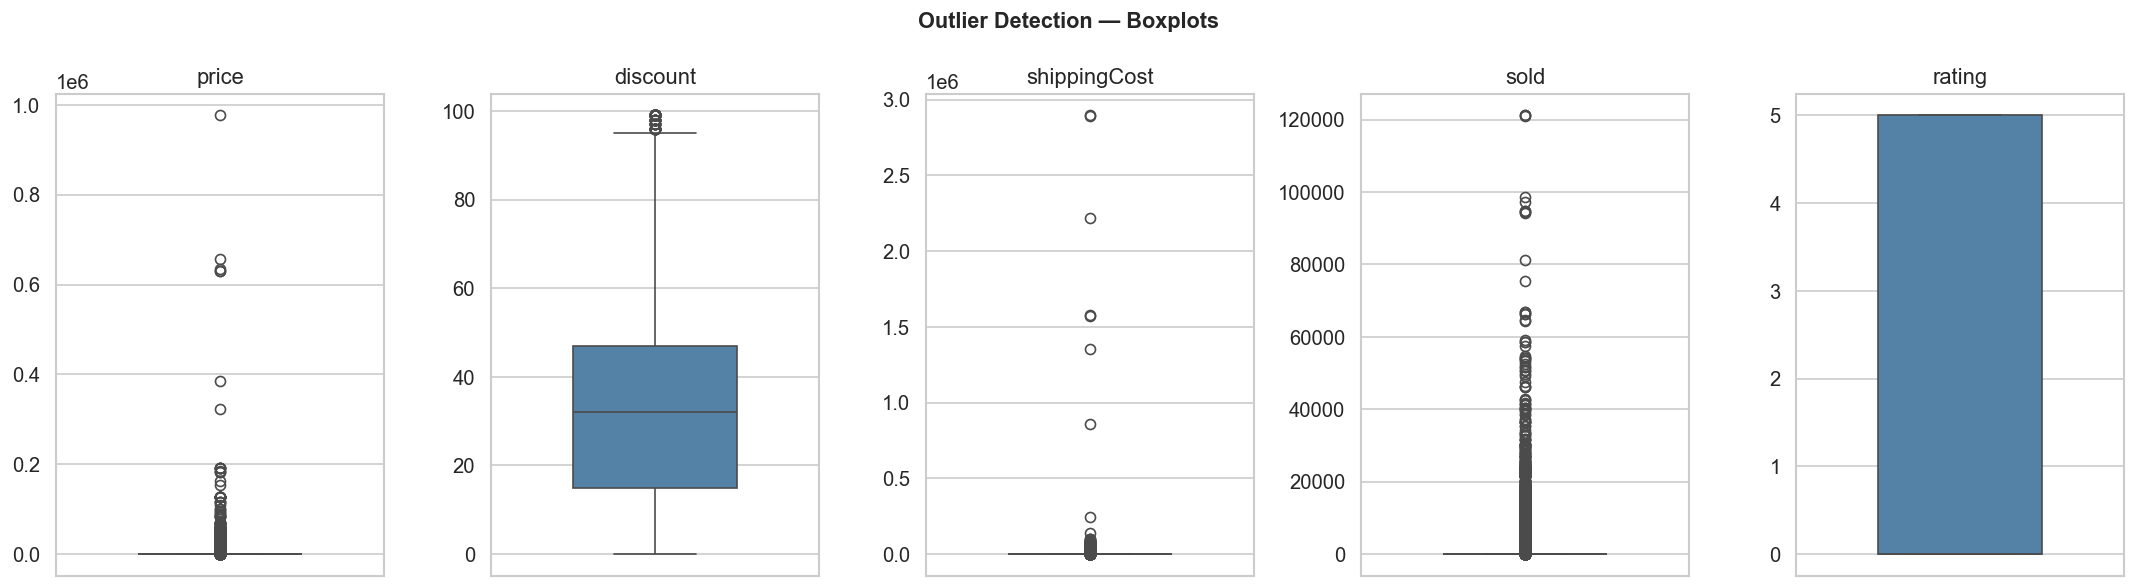

Outlier counts using IQR method:
----------------------------------------
  price          : 96979 outliers  (13.6%)
  discount       :  104 outliers  (0.0%)
  shippingCost   : 81023 outliers  (11.4%)
  sold           : 109499 outliers  (15.4%)
  rating         :    0 outliers  (0.0%)


In [50]:
numeric_cols = ['price', 'discount', 'shippingCost', 'sold', 'rating']
#  Boxplots
# The box shows Q1 to Q3 (middle 50% of data)
# The line inside is the median
# Dots beyond the whiskers = outliers
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(18, 5))

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='steelblue', width=0.5)
    axes[i].set_title(col)
    axes[i].set_ylabel('')

plt.suptitle('Outlier Detection — Boxplots', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
# ── IQR method ────────────────────────────────
print("Outlier counts using IQR method:")
print("-" * 40)
for col in numeric_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR #floor : below it is outlier 
    upper_bound = Q3 + 1.5 * IQR # ceiling : above it is outlier 
    n_outliers  = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    print(f"  {col:<15}: {n_outliers:>4} outliers  ({n_outliers/len(df)*100:.1f}%)")

how to deal with those outliers? 
we should not drop : price(13.6%),sold(15.4%),shippingCost(11.4%) > too much data to drop 
use Winsorize: keeps rows, just caps extreme values. keep 'discount' and'rating'.

Winsorization is a way of handling the impact of extreme values or outliers.

The statistical method involves capping your data and replacing the most extreme points—those that don’t fit the rest of your data—with less extreme values from the same dataset.

Teams use this technique to keep the data as close to its original form as possible while minimizing the influence of anomalies in their results.

In [51]:
from scipy.stats.mstats import winsorize

In [52]:
#capping is replacing extreme values with a boundary value instead of deleting the row 
# price
lower_p, upper_p = df['price'].quantile(0.01), df['price'].quantile(0.99)
df['price'] = df['price'].clip(lower=lower_p, upper=upper_p)
print(f"✓ price  capped at [{lower_p:.2f} → {upper_p:.2f}]")

# shippingCost 
lower_s, upper_s = df['shippingCost'].quantile(0.01), df['shippingCost'].quantile(0.99)
df['shippingCost'] = df['shippingCost'].clip(lower=lower_s, upper=upper_s)
print(f"✓ shippingCost  capped at [{lower_s:.2f} → {upper_s:.2f}]")

# sold 
#  sold is your most important feature (measures strategy success)
# We cap gently at 99th percentile to preserve high-performing products
lower_sold, upper_sold = df['sold'].quantile(0.01), df['sold'].quantile(0.99)
df['sold'] = df['sold'].clip(lower=lower_sold, upper=upper_sold)
print(f"✓ sold  capped at [{lower_sold:.2f} → {upper_sold:.2f}]")

#  discount(104 outliers = 0.01% → just cap to be safe)
lower_d, upper_d = df['discount'].quantile(0.01), df['discount'].quantile(0.99)
df['discount'] = df['discount'].clip(lower=lower_d, upper=upper_d)
print(f"✓ discount   capped at [{lower_d:.2f} → {upper_d:.2f}]")


✓ price  capped at [1.62 → 3270.70]
✓ shippingCost  capped at [0.00 → 799.10]
✓ sold  capped at [0.00 → 1342.00]
✓ discount   capped at [0.00 → 79.00]


Verifying outliers 

In [53]:
print("\nOutlier counts after treatment:")

numeric_cols = ['price', 'discount', 'shippingCost', 'sold', 'rating']
for col in numeric_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    n_outliers  = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    print(f"  {col:<15}: {n_outliers:>6} outliers  ({n_outliers/len(df)*100:.1f}%)")


Outlier counts after treatment:
  price          :  96979 outliers  (13.6%)
  discount       :      0 outliers  (0.0%)
  shippingCost   :  81023 outliers  (11.4%)
  sold           : 109499 outliers  (15.4%)
  rating         :      0 outliers  (0.0%)


## correlation Analysis 
Correlation measures how strongly two variables move together:
- **+1** = perfect positive correlation (when X goes up, Y goes up)
- **-1** = perfect negative correlation (when X goes up, Y goes down)
- **0**  = no relationship
This step helps us understand which variables are related to `sold`  
— which is the core of our pricing strategy analysis.

correlation heatmap

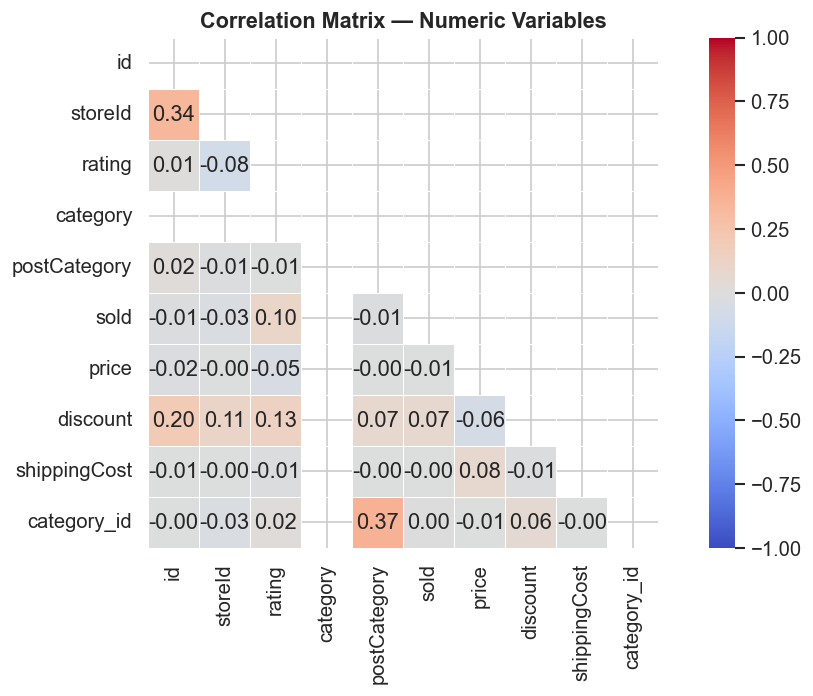

In [25]:
# 1. Clean 'sold' safely — handles both string and already-numeric values
df['sold'] = (
    df['sold']
    .astype(str)                          # force everything to string first
    .str.replace('sold', '', case=False)  # remove the word "sold"
    .str.replace(',', '')                 # remove commas if any (e.g. "1,487 sold")
    .str.strip()                          # remove whitespace
    .replace('', np.nan)                  # empty strings → NaN
    .astype(float)                        # now safely convert
)

#  Update numeric cols
numeric_cols = df.select_dtypes(include=['number']).columns

# 3Heatmap
plt.figure(figsize=(9, 6))
corr_matrix = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    mask=mask,
    square=True,
    linewidths=0.5,
    vmin=-1, vmax=1
)
plt.title('Correlation Matrix — Numeric Variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Rating & Sold (0.10): There is a very weak positive correlation. This suggests that a higher rating doesn't automatically guarantee massive sales in this specific dataset.

Discount & Rating (0.13): A slight positive correlation—customers might be giving slightly better ratings when they feel they got a deal

scatter plots 

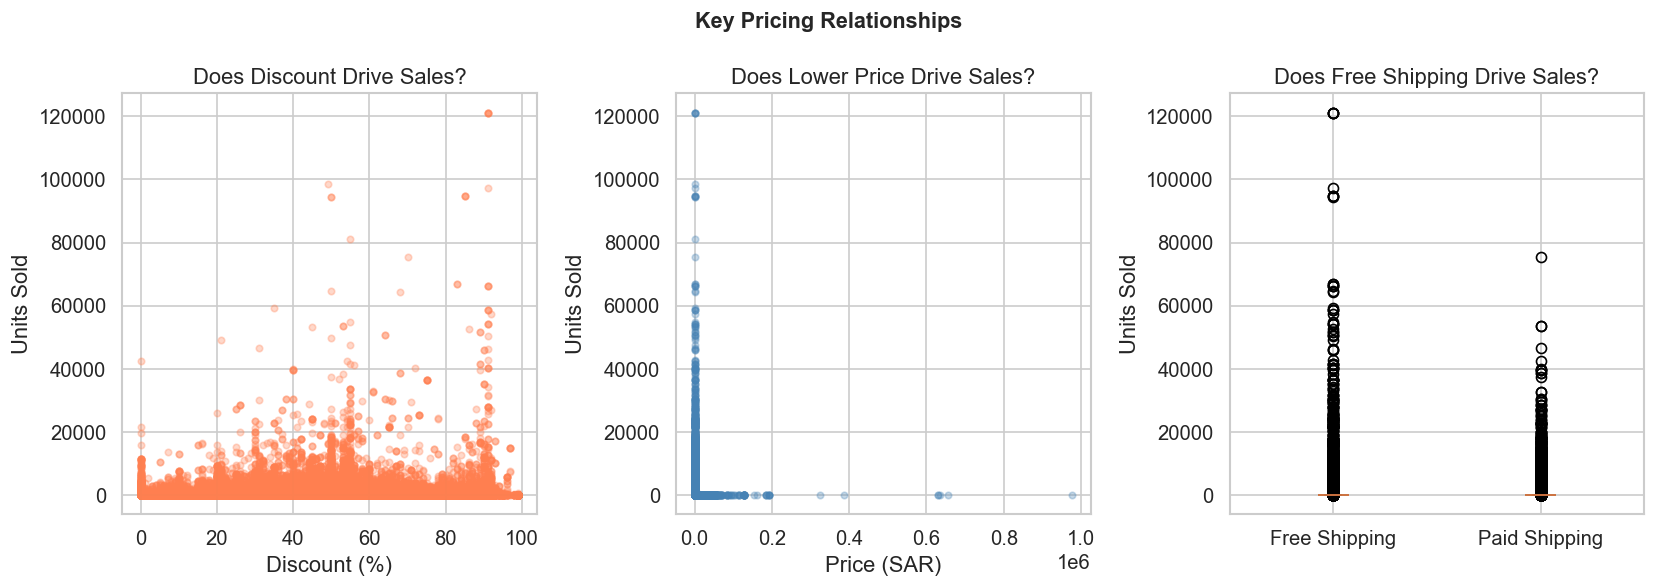

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
# Do higher discounts = more sales?
# This directly tests the "Aggressive Discounter" hypothesis
axes[0].scatter(df['discount'], df['sold'], alpha=0.3, color='coral', s=15)
axes[0].set_xlabel('Discount (%)')
axes[0].set_ylabel('Units Sold')
axes[0].set_title('Does Discount Drive Sales?')
# Do lower prices = more sales?
axes[1].scatter(df['price'], df['sold'], alpha=0.3, color='steelblue', s=15)
axes[1].set_xlabel('Price (SAR)')
axes[1].set_ylabel('Units Sold')
axes[1].set_title('Does Lower Price Drive Sales?')
# Does free shipping = more sales?
free_shipping    = df[df['shippingCost'] == 0]['sold']   # group: free shipping
paid_shipping    = df[df['shippingCost'] >  0]['sold']   # group: paid shipping
axes[2].boxplot(
    [free_shipping, paid_shipping],
    labels=['Free Shipping', 'Paid Shipping'],
    patch_artist=True,
    boxprops=dict(facecolor='mediumseagreen', color='black')
)
axes[2].set_ylabel('Units Sold')
axes[2].set_title('Does Free Shipping Drive Sales?')

plt.suptitle('Key Pricing Relationships', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
#add does free shipping 

**plot1** : 

usually higher discounts attract more buyers

**plot2** : 

usually cheaper products sell more 

**plot 3** : 

Even a small shipping fee  can feel disproportionately large

# Feature Engineering

Raw columns like `price` and `discount` exist independently.
But what really matters for pricing strategy is **how they combine**.

We create 7 new features that capture **seller behaviour patterns**:

---

## Features Overview


 | #  | Feature                  | Formula / Logic                              | What It Captures                                      |
 |----|--------------------------|----------------------------------------------|-------------------------------------------------------|
 | 1  | effective_price          | price × (1 - discount/100)                   | Real price paid after discount — truer cost signal    |
 | 2  | discount_aggressiveness  | discount × sold                              | How much discounting actually drove volume            |
 | 3  | free_shipping_flag       | 1 if shippingCost == 0 else 0                | Psychological pricing trigger — removes hidden tax    |
 | 4  | value_score              | (sold × rating) / (effective_price + 1)      | Perceived value: quality × popularity per price unit  |
 | 5  | listing_month            | lunchTime.dt.month                           | Seasonality effect — winter months may boost sales    |
 | 6  | price_vs_category_avg    | price / mean(price in category)              | Positioning: >1 = premium, <1 = budget                |
 | 7  | store_avg_discount       | mean(discount) per storeId                   | Store pricing personality — always-on promo vs normal |
 | 8  | sales_per_discount       | sold / (discount + 1)                        | Discount efficiency — units gained per % off          |
 | 9  | is_ad                    | 1 if type == 'ad' else 0                     | Paid vs organic listing — traffic source signal       |
 | 10 | price_rank_in_category   | percentile rank of price in category_id      | Market position: 0 = cheapest, 1 = most expensive     |
 | 11 | discount_rank_in_category| percentile rank of discount in category_id   | Discount aggression relative to category competitors  |
 | 12 | total_cost               | effective_price + shippingCost               | True buyer cost including shipping                    |
 | 13 | store_avg_sold           | mean(sold) per storeId                       | Store popularity / brand strength proxy               |
# ─────────────────────────────────────────────────────────────────────────────
---

## Feature Details

### `effective_price`
The real final price the buyer pays after discount is applied.
More honest than raw price for comparisons.

### `discount_aggressiveness`
Measures how extreme the discount is.
A seller always at 5% off is mild. A seller at 60% off is aggressive — possibly inflating original prices to fake big deals.

### `free_shipping`
Binary flag: **1** = seller absorbs shipping cost, **0** = buyer pays.
Offering free shipping is a competitive strategy — it effectively lowers the final price.

### `value_score`
Determines the **true value** of an item by combining quality and price:
- High rating + low price → **great deal**
- Same rating + high price → **bad deal**

> Same quality, cheaper price always wins.

### `listing_month`
The month the product was listed. Captures **seasonal behaviour** such as:
- Ramadan discounts
- Back-to-school spikes
- Summer sales

### `price_vs_category_avg`
Compares a product's price to the **average price in its category**.
Reveals seller positioning strategy:
- Price **above** average → **Premium positioning** (signals higher quality, exclusivity)
- Price **below** average → **Budget positioning** (targets price-sensitive buyers)

> Luxury brands deliberately price high to signal inherent value — consumers partly judge quality by price.

### `store_avg_discount`
The average discount across **all of a store's listings**.
- Low average (5–10%) → discounts are genuine and occasional
- High average (40%+) → discounting is a **permanent strategy**, possibly with inflated base prices

### `Sales efficiency per discount point`
 "How many units sold per % of discount applied?"
 High value = sales driven by quality/demand, not just price cuts

### `is_ad`
 whether the listing is a paid ad or an organic result
### `'price_rank_in_category'`
 Percentile rank of this product's price among all products in the same category. 0 = cheapest in category / 1 = most expensive in category.
 
### `'discount_rank_in_category'`
 How aggressive is this discount relative to competitors in the same category?.0 = lowest discount /1 = highest discount in category

### `'total_cost'`
discounted price + shipping

### `'store_avg_sold'`
 Average units sold across all of this store's products

### 
**Features: Effective Price / Discount Aggressiveness / Sales per Discount**
Effects of price discount on consumers’perceptions of savings, quality, and value
for apparel products: mediating effect of price
discount affect


---


# Refrences and justifications : 
Scientific articles and sources behind each engineered feature
## Features 1, 2, 8 — Effective Price / Discount Aggressiveness / Sales per Discount

**[1] Lee, S., & Stoel, L. (2014)**  
"Effects of price discount on consumers' perceptions of savings, quality, and value for apparel products."  
Fashion and Textiles, Springer Open.  
- Examines how discount levels (10–70%) affect perceived value and purchase intention  
- Justifies using discount as a feature  
Link: https://fashionandtextiles.springeropen.com/articles/10.1186/s40691-018-0128-2  

**[2] Tang et al. (2024)**  
"How do e-commerce platforms and retailers implement discount pricing policies under strategic consumers?"  
PLOS ONE.  
- Game-theory model of discount competition  
- Supports discount_aggressiveness and effective_price  
Link: https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0296654  

**[3] ScienceDirect (2025)**  
"Impact of at-purchase and post-purchase discounts on customers' return behavior."  
- Strongest sales impact in 45–55% discount range  
- Supports non-linear discount effects  
Link: https://www.sciencedirect.com/science/article/pii/S0022435925000375  

**[4] Shekhawat et al. (2020)**  
"A Study on the Impact of Discounts."  
- Discounts drive impulse buying  
- Frequent discounts may reduce brand loyalty  
- Supports sales_per_discount  
Link: https://ijcrt.org/papers/IJCRT2004117.pdf  

---

## Feature 3 — Free Shipping Flag

**[5] FedEx / Morning Consult (2024)**  
- 75% prioritize free shipping over speed  
- 57% prioritize it over price  
Link: https://newsroom.fedex.com/newsroom/global-english/fedex-data-highlights-that-consumers-view-free-shipping-as-a-non-negotiable-for-cart-conversion  

**[6] Laroche et al.**  
"Free Shipping vs. Dollar Off: Consumer Preference for Online Discount."  
- Free shipping perceived as more valuable than equivalent discounts  
- Justifies free_shipping_flag  
Link: https://www.researchgate.net/publication/349345690  

**[7] Invesp (2017)**  
- 93% of buyers purchase more with free shipping  
- More compelling than percentage discounts  
Link: https://www.invespcro.com/blog/free-shipping/  

---

## Feature 4 — Value Score (sold × rating / effective_price)

**[8] Spiegel Research Center (2017)**  
"How Online Reviews Influence Sales."  
- Optimal ratings range: 4.0–4.7  
- Reviews increase conversion by 270%  
Link: https://spiegel.medill.northwestern.edu/how-online-reviews-influence-sales/  

**[9] 1WorldSync (2025)**  
"How Ratings and Reviews Impact E-Commerce Sales."  
- 108.3% conversion increase when interacting with ratings  
- Supports including rating in value_score  
Link: https://1worldsync.com/resource-center/blog/how-ratings-and-reviews-impact-e-commerce-sales/  

---

## Features 6, 10 — Price vs Category Avg / Price Rank in Category

**[10] Karakaya et al. (2022)**  
"Competitive Pricing on Online Markets: A Literature Review."  
- Relative pricing drives sales rank  
Link: https://pmc.ncbi.nlm.nih.gov/articles/PMC9194889/  

**[11] MIT (2022)**  
"An Empirical Study of Pricing Strategies in an Online Market."  
- Lower price ranking leads to higher sales  
Link: https://economics.mit.edu/sites/default/files/publications/repeat27.pdf  

**[12] JETIR (2023)**  
"The Effects of Pricing Strategies on E-Commerce Consumer Behaviour."  
- Competitive pricing strongly influences purchasing decisions  
Link: https://www.jetir.org/papers/JETIR2301616.pdf  

---

## Features 7, 13 — Store Avg Discount / Store Avg Sold

**[13] Deloitte Consumer Study (2025)**  
- Store trust and reputation drive repeat purchases  
- Free shipping increases return rate  
Link: https://www.sellerscommerce.com/blog/free-shipping-statistics/  

---

## Feature 11 — Discount Rank in Category

**[14] IJFMR (2025)**  
"Psychology of Discounts in E-Commerce."  
- Discounts are perceived relative to category norms  
- Extreme discounts may signal low quality  
Link: https://www.ijfmr.com/papers/2025/1/37267.pdf  

---

## Feature 12 — Total Cost to Buyer

**[15] Statista / Acowebs (2024)**  
"How Shipping Costs Affect E-Commerce Conversion Rates."  
- 63% of cart abandonment caused by high shipping cost  
- Supports using total_cost = price + shipping  
Link: https://acowebs.com/ecommerce-shipping-rates/  

In [57]:
# Feature 1: Effective price 
# The actual price paid after applying the discount
# Formula used : price × (1 - discount/100)
df['effective_price'] = df['price'] * (1 - df['discount'] / 100)


# Feature 2: Discount aggressiveness
# discount × sold = how much the seller pushed discounts AND how well it worked
# High value → "Aggressive Discounter" archetype
df['discount_aggressiveness'] = df['discount'] * df['sold']

# Feature 3: Free shipping flag 
# Binary: 1 if seller offers free shipping, 0 otherwise
# Free shipping is a known psychological sales trigger in KSA
df['free_shipping_flag'] = (df['shippingCost'] == 0).astype(int)

# New: normalize each component first
df['value_score'] = (df['sold'] * df['rating']) / (df['effective_price'] + 1)


# Feature 5: Listing month
# Extract month from lunchTime (the date the product was listed)
# Products listed in winter (Nov-Dec) may benefit from seasonal demand
df['lunchTime']     = pd.to_datetime(df['lunchTime'], errors='coerce')
df['listing_month'] = df['lunchTime'].dt.month
df['listing_year']  = df['lunchTime'].dt.year

# Feature 6: Price vs category average 
# Compares a product's price to the average in its category
# > 1 = premium positioning, < 1 = budget positioning
cat_avg = df.groupby('category_name')['price'].transform('mean')
df['price_vs_category_avg'] = df['price'] / cat_avg.replace(0, np.nan)
df['price_vs_category_avg'] = df['price_vs_category_avg'].fillna(1)

# Feature 7: Store average discount
# Average discount offered by this store across ALL its products
# High value = this store is structurally promotional (always discounting)
df['store_avg_discount'] = df.groupby('storeId')['discount'].transform('mean')


# 8. Sales efficiency per discount
# "How many units sold per % of discount applied?"
df['sales_per_discount'] = df['sold'] / (df['discount'] + 1)

# 9. Is ad or organic (encode type column)
df['is_ad'] = (df['type'] == 'ad').astype(int)

# 10. Price competitiveness rank within category
#market position of the product  to other competotors 
df['price_rank_in_category'] = df.groupby('category_id')['price'] \
                                  .rank(pct=True)  # 0=cheapest, 1=most expensive

# 11. Discount rank within category
# how aggressive discount according to the category 
df['discount_rank_in_category'] = df.groupby('category_id')['discount'] \
                                     .rank(pct=True)  # 0=lowest discount, 1=highest


# 12. Total cost to buyer
# price + shipping cost 
df['total_cost'] = df['effective_price'] + df['shippingCost']


# 13. Store performance score
# "How well does this store perform on average?"
#is it a popular or unkown storer (its popularity) 
df['store_avg_sold'] = df.groupby('storeId')['sold'].transform('mean')

# new features
engineered_features = ['effective_price', 'discount_aggressiveness', 'free_shipping_flag',
              'value_score', 'listing_month', 'price_vs_category_avg',
              'store_avg_discount', 'sales_per_discount', 'is_ad',
              'price_rank_in_category', 'discount_rank_in_category',
              'total_cost', 'store_avg_sold']

print("Engineered features: ")
print(df[engineered_features].describe().round(2))
print(f"\n  {len(engineered_features)} feature engineered successfully")

Engineered features: 
       effective_price  discount_aggressiveness  free_shipping_flag  \
count        711168.00                711168.00           711168.00   
mean            132.79                  1989.97                0.36   
std             384.92                  8267.20                0.48   
min               0.34                     0.00                0.00   
25%               8.89                     0.00                0.00   
50%              25.46                    51.00                0.00   
75%              76.90                   540.00                1.00   
max            3270.70                106018.00                1.00   

       value_score  listing_month  price_vs_category_avg  store_avg_discount  \
count    711168.00      711168.00              711168.00           711168.00   
mean         32.05           7.52                   1.00               30.59   
std         180.09           3.07                   2.40               18.06   
min           0.00

discount_aggressiveness :huge range : so log transform 
price_vs_category_avg : max = 176 : capping 

fixing skewed features : 

In [58]:
skewed_engineered = [
    'effective_price',
    'discount_aggressiveness', 
    'value_score',
    'sales_per_discount',
    'store_avg_sold',
    'total_cost'
]

for col in skewed_engineered:
    df[col] = np.log1p(df[col])
    print(f" log1p applied to {col}")

# Cap price_vs_category_avg
cap = df['price_vs_category_avg'].quantile(0.99)
df['price_vs_category_avg'] = df['price_vs_category_avg'].clip(upper=cap)
print(f"price_vs_category_avg capped at {cap:.2f}")

 log1p applied to effective_price
 log1p applied to discount_aggressiveness
 log1p applied to value_score
 log1p applied to sales_per_discount
 log1p applied to store_avg_sold
 log1p applied to total_cost
price_vs_category_avg capped at 8.87


Visualising engineered features

we have extreme outliers that pulls x-axis to 1.000.000.. , so most of the data is squished to 0 >so log-scale it 

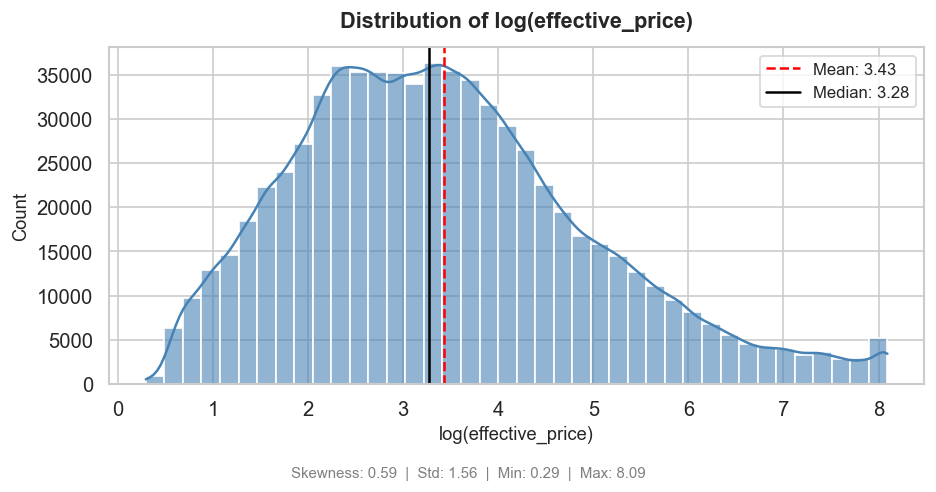

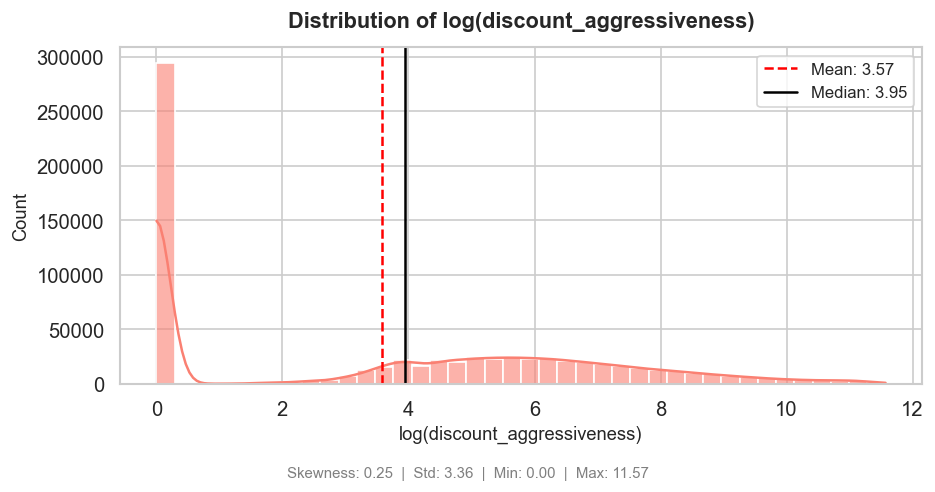

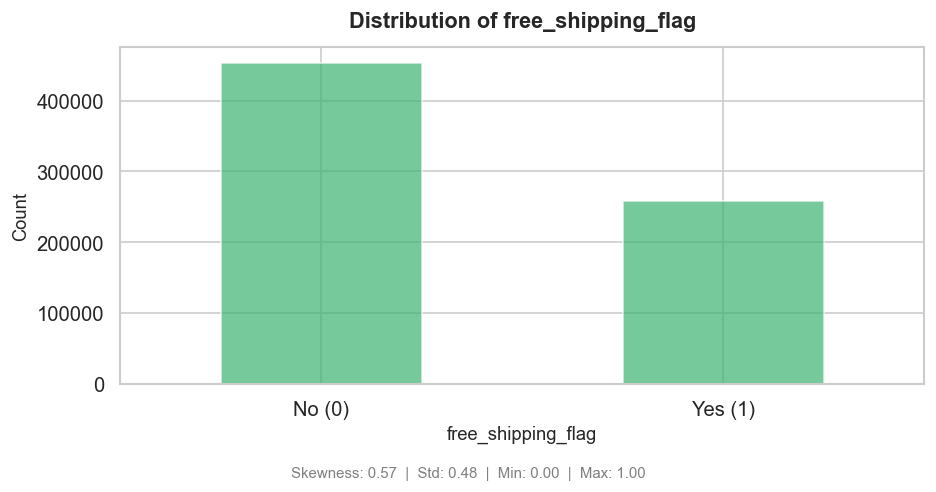

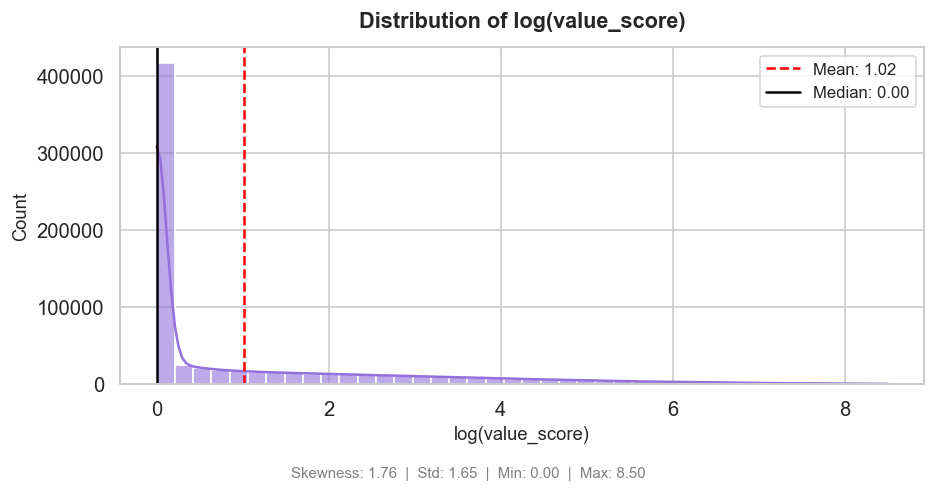

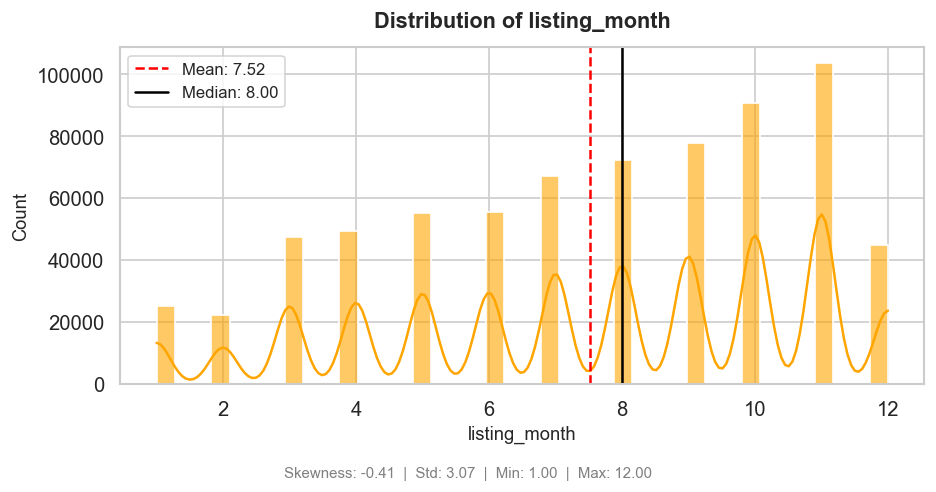

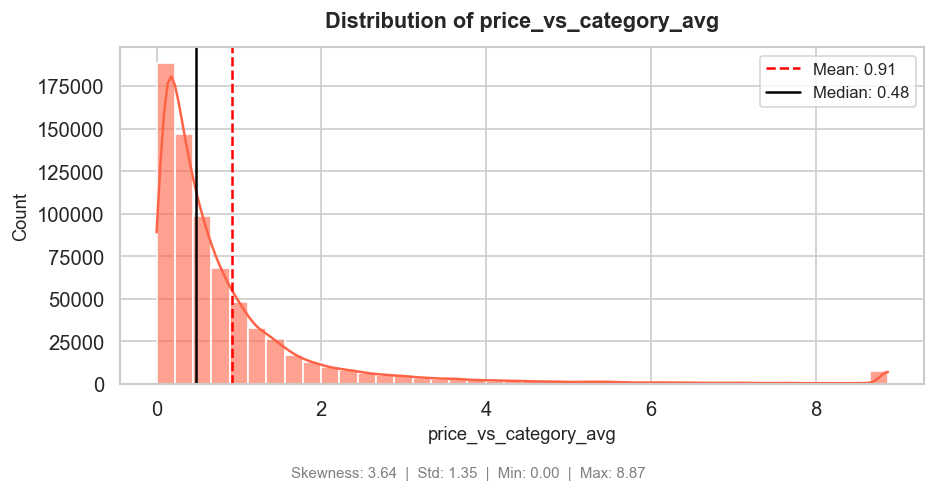

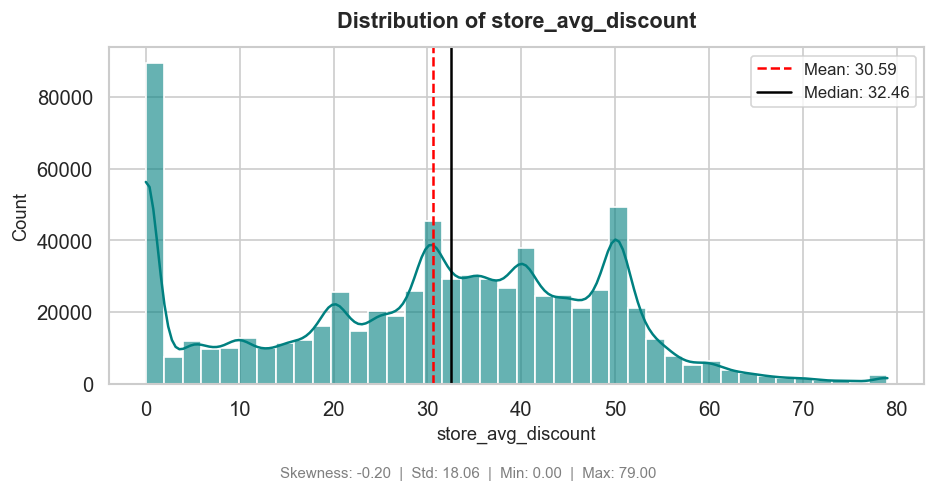

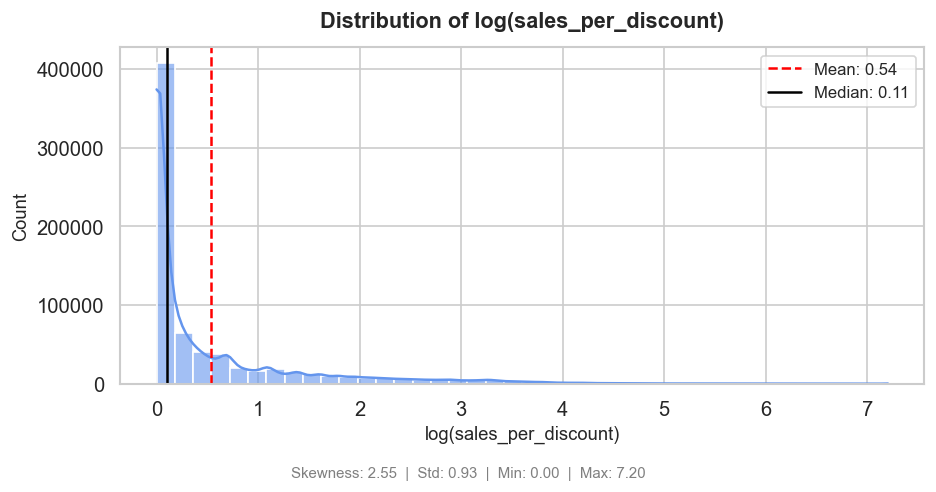

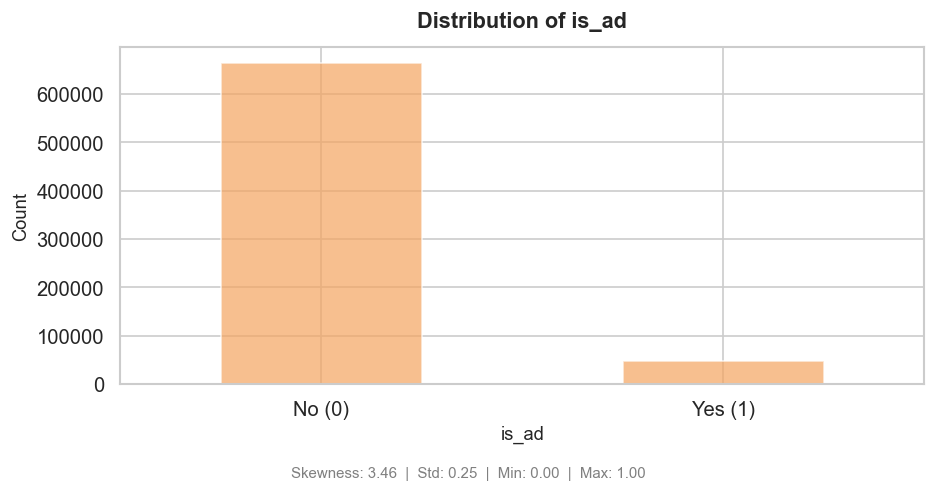

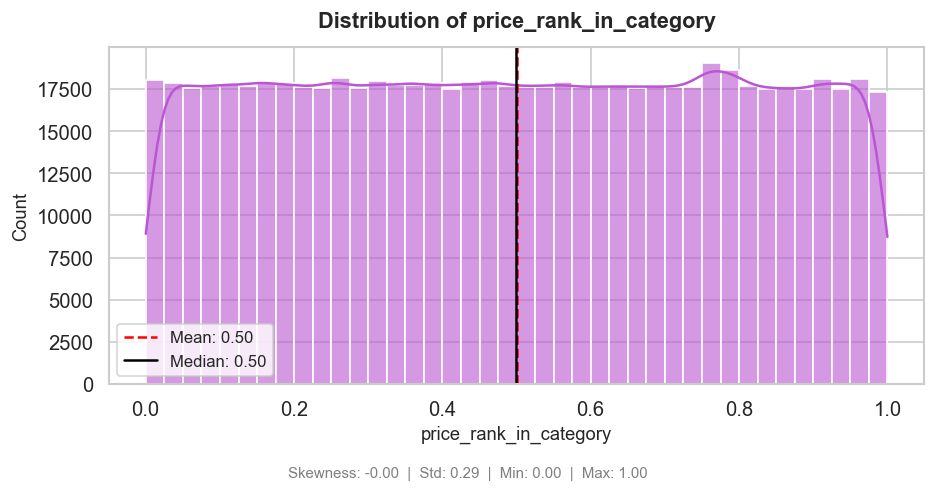

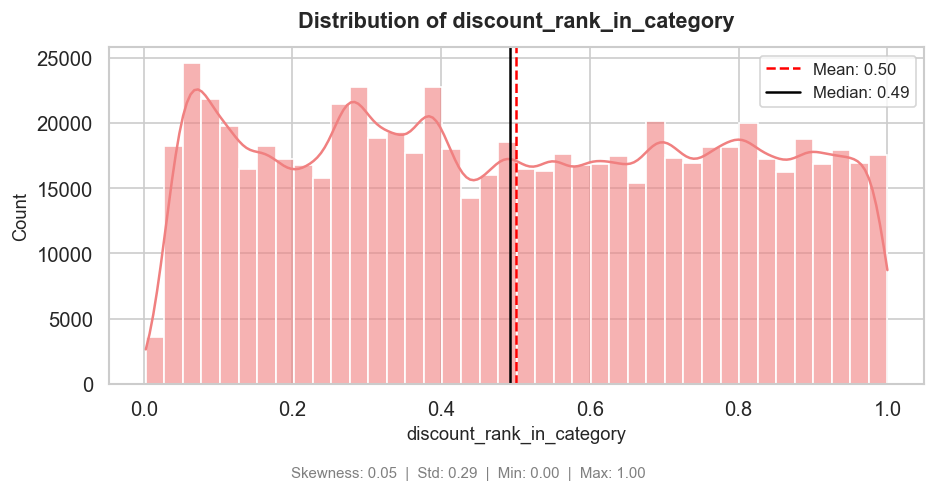

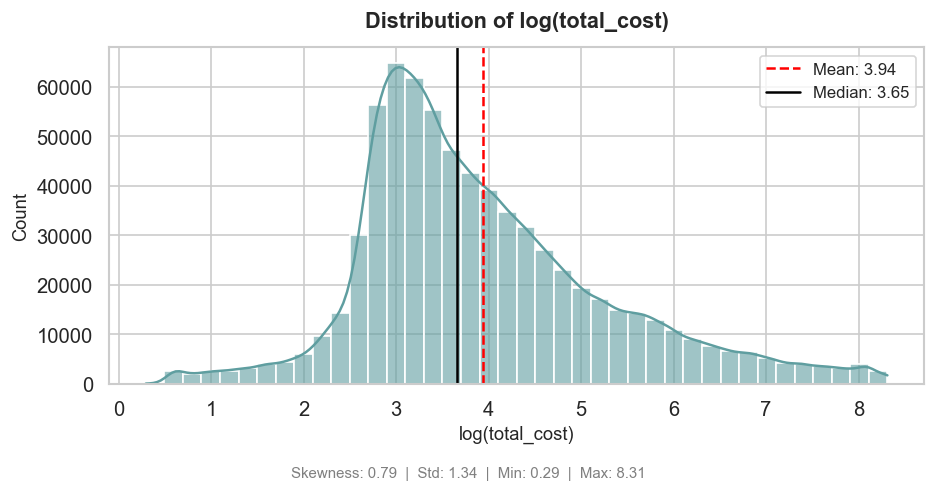

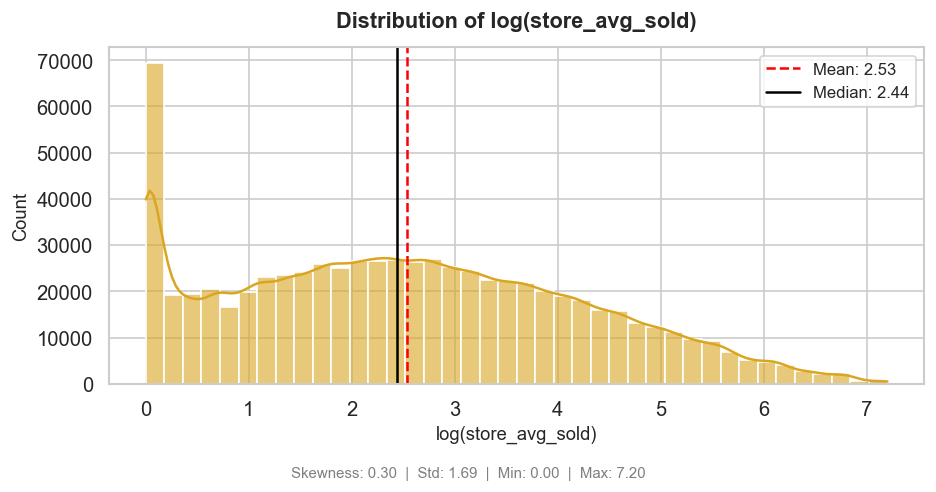

In [59]:
engineered_features = [
    'effective_price', 'discount_aggressiveness', 'free_shipping_flag',
    'value_score', 'listing_month', 'price_vs_category_avg',
    'store_avg_discount', 'sales_per_discount', 'is_ad',
    'price_rank_in_category', 'discount_rank_in_category',
    'total_cost', 'store_avg_sold'
]

# which ones got log transformed (for title label)
log_transformed = [
    'effective_price', 'discount_aggressiveness',
    'value_score', 'sales_per_discount',
    'store_avg_sold', 'total_cost'
]

colors = [
    'steelblue', 'salmon', 'mediumseagreen', 'mediumpurple',
    'orange', 'tomato', 'teal', 'cornflowerblue', 'sandybrown',
    'mediumorchid', 'lightcoral', 'cadetblue', 'goldenrod'
]

for i, col in enumerate(engineered_features):
    fig, ax = plt.subplots(figsize=(8, 4))
    data = df[col].dropna()

    # binary columns → bar chart instead of histogram
    if col in ['free_shipping_flag', 'is_ad']:
        data.value_counts().sort_index().plot(kind='bar', color=colors[i],
                                              alpha=0.7, edgecolor='white', ax=ax)
        ax.set_xticklabels(['No (0)', 'Yes (1)'], rotation=0)
    else:
        sns.histplot(data, bins=40, color=colors[i], alpha=0.6,
                     edgecolor='white', ax=ax, kde=True)
        ax.axvline(data.mean(),   color='red',   linestyle='--',
                   linewidth=1.5, label=f'Mean: {data.mean():.2f}')
        ax.axvline(data.median(), color='black', linestyle='-',
                   linewidth=1.5, label=f'Median: {data.median():.2f}')
        ax.legend(fontsize=10)

    # title — add log() label if transformed
    label = f'log({col})' if col in log_transformed else col
    ax.set_title(f'Distribution of {label}', fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel('Count', fontsize=11)

    # stats footer
    fig.text(0.5, -0.02,
             f'Skewness: {data.skew():.2f}  |  Std: {data.std():.2f}  |  '
             f'Min: {data.min():.2f}  |  Max: {data.max():.2f}',
             ha='center', fontsize=9, color='gray')

    plt.tight_layout()
    plt.show()

# Discount tiers analysis
Tiered discounting is a pricing strategy where customers get greater discounts as they buy more or spend more. 

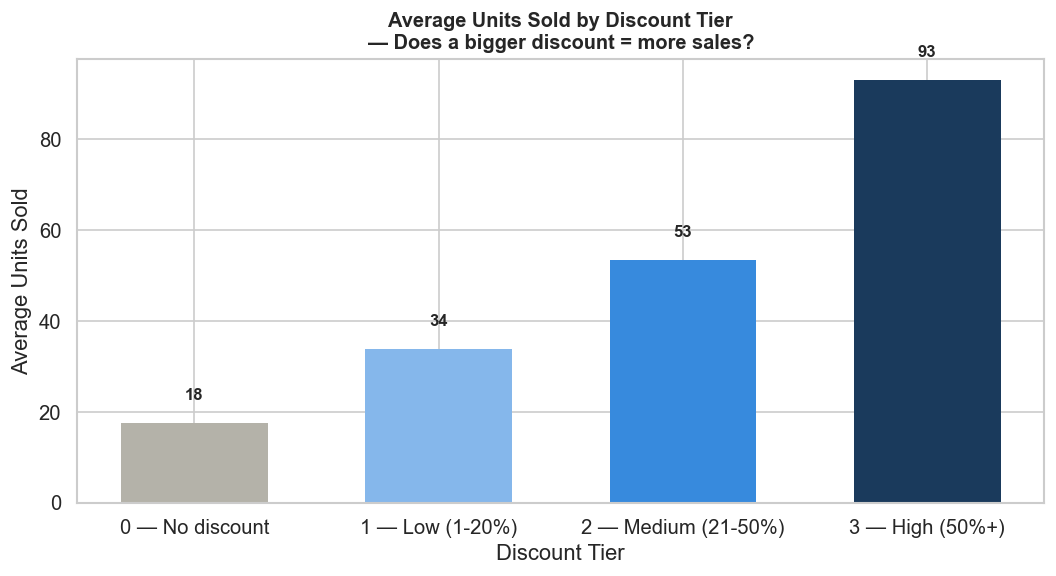

In [61]:
# We group products into 4 discount buckets to see which tier sells best
def discount_tier(d):
    if d == 0:
        return '0 — No discount'
    elif d <= 20:
        return '1 — Low (1-20%)'
    elif d <= 50:
        return '2 — Medium (21-50%)'
    else:
        return '3 — High (50%+)'

df['discount_tier'] = df['discount'].apply(discount_tier)
# Average units sold per tier
tier_sold = df.groupby('discount_tier')['sold'].mean().sort_index()

plt.figure(figsize=(9, 5))
bars = plt.bar(
    tier_sold.index, tier_sold.values,
    color=['#B4B2A9', '#85B7EB', '#378ADD', '#1A3A5C'],
    edgecolor='none', width=0.6
)
plt.title('Average Units Sold by Discount Tier\n'
          '— Does a bigger discount = more sales?',
          fontsize=12, fontweight='bold')
plt.xlabel('Discount Tier')
plt.ylabel('Average Units Sold')

# Add value labels on top of each bar
for bar, val in zip(bars, tier_sold.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{val:.0f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()



In [ ]:
Save the enriched dataset

In [62]:
#save the dataframe with all new features added
df.to_csv('df_enriched.csv', index=False)
print(f" Saved df_enriched.csv")
print(f"  Shape    : {df.shape}")
print(f"  Columns  : {df.columns.tolist()}")

 Saved df_enriched.csv
  Shape    : (711168, 26)
  Columns  : ['storeId', 'rating', 'lunchTime', 'sold', 'price', 'discount', 'shippingCost', 'storeUrl', 'category_name', 'category_id', 'type', 'effective_price', 'discount_aggressiveness', 'free_shipping_flag', 'value_score', 'listing_month', 'listing_year', 'price_vs_category_avg', 'store_avg_discount', 'sales_per_discount', 'is_ad', 'price_rank_in_category', 'discount_rank_in_category', 'total_cost', 'store_avg_sold', 'discount_tier']
